# Cluster 3 — comparação dados diários vs. horários

Levantamento de dados (sem treino de modelo) para decidir o escopo de estações
do experimento diário-vs-horário do Cluster 3. Compara:

- o dataset ERA5 horário do Cluster 3 (`dataset/raw/test_cluster_3_hourly.nc`)
- a base diária que a pipeline `cluster_lstm`/`cluster_mlp`/`cluster_lazy` usa hoje
  (`dataset/raw/INMET_Stratified.nc` + `dataset/raw/ERA5_Stratified.nc`, via
  `src.data.netcdf_loader.NetCDFLoader`)
- o Cluster 3 definido hoje pelo shapefile (`dataset/shp/shp_vento.shp`)

Todos os números abaixo (quantidade de estações, período coberto, quais têm
alvo válido) são lidos diretamente dos arquivos em cada célula — nada é
digitado à mão, então o notebook continua correto se os arquivos mudarem.

Este notebook não treina nada — é só para embasar a decisão de quais estações
entram no experimento diário-vs-horário.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Markdown, display

sys.path.insert(0, "..")
from src.data.cluster_assigner import assign_station_clusters
from src.data.netcdf_loader import NetCDFLoader
from src.pipelines.common import TRAIN_SLICE, VAL_SLICE, TEST_SLICE

RAW_DIR = Path("../dataset/raw")
SHP_DIR = Path("../dataset/shp")
HOURLY_PATH = RAW_DIR / "test_cluster_3_hourly.nc"
INMET_CURRENT_PATH = RAW_DIR / "INMET_Stratified.nc"
INMET_BACKUP_PATH = RAW_DIR / "INMET_Stratified.nc.bak-pre-paired-csv-migration"
MASK_PATH = Path("../artifacts/cluster_masks/cluster_3_mask.geojson")

# Único parâmetro fixado de propósito: qual cluster estamos investigando.
# Tudo o mais (estações, período, cobertura) é lido dos arquivos abaixo.
TARGET_CLUSTER = 3

ds_hourly = xr.open_dataset(HOURLY_PATH)
HOURLY_STATIONS = sorted(str(s) for s in ds_hourly["estacao"].values)
print(f"Estações no arquivo horário (lido do arquivo): {len(HOURLY_STATIONS)}")
print(HOURLY_STATIONS)

Estações no arquivo horário (lido do arquivo): 21
['A801', 'A834', 'A840', 'A878', 'A879', 'A882', 'A884', 'A893', 'B807', 'B808', 'B809', 'B810', 'B811', 'B812', 'B813', 'B814', 'B816', 'B818', 'B819', 'B820', 'B825']


## Roster do Cluster 3 hoje

Reconstrói as estações do Cluster 3 via o mesmo spatial join
(`assign_station_clusters`) que a pipeline principal usa — a contagem sai do
próprio join, não é assumida aqui.

In [2]:
ds_inmet_current = xr.open_dataset(INMET_CURRENT_PATH)

station_clusters = assign_station_clusters(ds_inmet_current, str(SHP_DIR))
cluster3_stations = station_clusters[station_clusters["cluster_id"] == TARGET_CLUSTER]
cluster3_stations = cluster3_stations.merge(
    ds_inmet_current[["latitude", "longitude"]].to_dataframe().groupby("estacao").first().reset_index(),
    on="estacao", how="left",
)
print(f"Cluster {TARGET_CLUSTER} hoje: {len(cluster3_stations)} estações (contagem lida do spatial join)")

faltando_no_hourly = sorted(set(cluster3_stations["estacao"]) - set(HOURLY_STATIONS))
extra_no_hourly = sorted(set(HOURLY_STATIONS) - set(cluster3_stations["estacao"]))
print(f"No Cluster 3 mas ausentes do arquivo horário: {faltando_no_hourly or 'nenhuma'}")
print(f"No arquivo horário mas fora do Cluster 3 (spatial join atual): {extra_no_hourly or 'nenhuma'}")
cluster3_stations

Cluster 3 hoje: 21 estações (contagem lida do spatial join)
No Cluster 3 mas ausentes do arquivo horário: nenhuma
No arquivo horário mas fora do Cluster 3 (spatial join atual): nenhuma


,estacao,cluster_id,latitude,longitude
0,A801,3,-30.0536,-51.1747
1,A834,3,-30.0103,-50.1358
2,A840,3,-29.1644,-51.5342
3,A878,3,-31.2483,-50.9064
4,A879,3,-29.3689,-50.8272
5,A882,3,-29.4492,-51.8233
6,A884,3,-29.6742,-51.0642
7,A893,3,-30.5431,-52.5247
8,B807,3,-30.1861,-51.1781
9,B808,3,-29.9514,-51.1242


## Cobertura do arquivo horário

Para cada estação do arquivo horário (lista obtida na célula de setup),
verifica se tem alvo (`daily_wind_gust_max`) válido na base atual, se tem no
backup pré-migração, e se cai dentro do polígono do Cluster 3.

In [3]:
ds_inmet_backup = xr.open_dataset(INMET_BACKUP_PATH)
current_stations = set(str(s) for s in ds_inmet_current["estacao"].values)
backup_stations = set(str(s) for s in ds_inmet_backup["estacao"].values)
cluster3_ids = set(cluster3_stations["estacao"])


def _has_valid_target(ds, estacao):
    if estacao not in set(str(s) for s in ds["estacao"].values):
        return False
    serie = ds["daily_wind_gust_max"].sel(estacao=estacao)
    return bool(np.isfinite(serie.values).any())


rows = []
for est in HOURLY_STATIONS:
    tem_atual = est in current_stations and _has_valid_target(ds_inmet_current, est)
    tem_backup = est in backup_stations and _has_valid_target(ds_inmet_backup, est)
    rows.append({
        "estacao": est,
        "tem_alvo_atual": tem_atual,
        "tem_alvo_backup": tem_backup,
        "dentro_cluster3_hoje": est in cluster3_ids,
        "motivo": (
            "ok" if tem_atual
            else "sem alvo atual — só existe no backup pré-migração" if tem_backup
            else "sem alvo em nenhuma base"
        ),
    })

coverage_df = pd.DataFrame(rows)
coverage_df

,estacao,tem_alvo_atual,tem_alvo_backup,dentro_cluster3_hoje,motivo
0,A801,True,True,True,ok
1,A834,True,False,True,ok
2,A840,True,True,True,ok
3,A878,True,True,True,ok
4,A879,True,True,True,ok
5,A882,True,True,True,ok
6,A884,True,True,True,ok
7,A893,True,True,True,ok
8,B807,True,True,True,ok
9,B808,True,False,True,ok


## Mapa visual

Cluster 3 com suas estações, coloridas por categoria de cobertura do arquivo
horário.

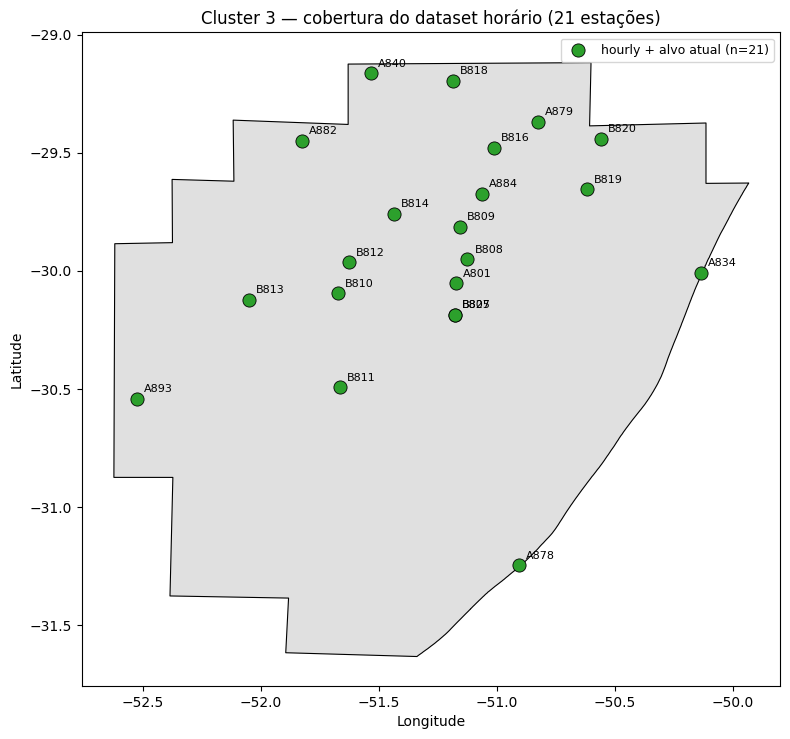

In [4]:
mask_c3 = gpd.read_file(MASK_PATH)

CATEGORY_COLORS = {
    "hourly + alvo atual": "#2ca02c",
    "hourly, sem alvo atual": "#d62728",
    "sem cobertura hourly": "#7f7f7f",
}


def _category(estacao):
    if estacao not in HOURLY_STATIONS:
        return "sem cobertura hourly"
    row = coverage_df.set_index("estacao").loc[estacao]
    return "hourly + alvo atual" if row["tem_alvo_atual"] else "hourly, sem alvo atual"


cluster3_stations = cluster3_stations.copy()
cluster3_stations["categoria"] = cluster3_stations["estacao"].apply(_category)

fig, ax = plt.subplots(figsize=(8, 8))
mask_c3.plot(ax=ax, color="#e0e0e0", edgecolor="black", linewidth=0.8)

for cat, color in CATEGORY_COLORS.items():
    sub = cluster3_stations[cluster3_stations["categoria"] == cat]
    if len(sub):
        ax.scatter(
            sub["longitude"], sub["latitude"], color=color, s=90,
            edgecolor="black", linewidth=0.6, label=f"{cat} (n={len(sub)})", zorder=5,
        )

for _, row in cluster3_stations.iterrows():
    if row["estacao"] in HOURLY_STATIONS:
        ax.annotate(
            row["estacao"], (row["longitude"], row["latitude"]),
            xytext=(5, 5), textcoords="offset points", fontsize=8,
        )

ax.set_title(f"Cluster {TARGET_CLUSTER} — cobertura do dataset horário ({len(cluster3_stations)} estações)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="best", fontsize=9)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Cobertura temporal

Range do arquivo horário (lido do próprio arquivo) vs. os slices de
treino/val/teste importados diretamente de `src/pipelines/common.py` — a
mesma constante que a pipeline principal usa, não uma cópia digitada aqui.

In [5]:
hourly_start, hourly_end = ds_hourly["time"].min().values, ds_hourly["time"].max().values
print(f"Arquivo horário: {hourly_start} até {hourly_end}  ({ds_hourly.sizes['time']:,} timesteps)")
print()
for name, (start, end) in [("train", TRAIN_SLICE), ("val", VAL_SLICE), ("test", TEST_SLICE)]:
    covered = (np.datetime64(start) >= hourly_start) and (np.datetime64(end) <= hourly_end)
    print(f"{name:5s} {start} .. {end}  coberto pelo horário: {covered}")

Arquivo horário: 2000-01-01T00:00:00.000000000 até 2025-12-31T23:00:00.000000000  (227,928 timesteps)

train 2008-01-01 .. 2018-12-31  coberto pelo horário: True
val   2019-01-01 .. 2019-12-31  coberto pelo horário: True
test  2020-01-01 .. 2025-12-31  coberto pelo horário: True


## Completude dos dados horários

Fração de NaN por variável e por estação, geral e restrita ao período de
treino/val/teste (`TRAIN_SLICE`/`VAL_SLICE`/`TEST_SLICE` importados acima).
Resumida por variável (mín/média/máx entre as estações) — a tabela completa
por estação também fica disponível em `missing_all`.

In [6]:
def _missing_table(ds, time_slice=None, label="completo"):
    d = ds.sel(time=slice(*time_slice)) if time_slice else ds
    frac_nan = {
        var: d[var].isnull().mean(dim="time").to_series()
        for var in d.data_vars
    }
    out = pd.DataFrame(frac_nan)
    out.index.name = "estacao"
    out["periodo"] = label
    return out.reset_index()


periodo_completo = f"{pd.Timestamp(hourly_start).date()}..{pd.Timestamp(hourly_end).date()} (completo)"
missing_full = _missing_table(ds_hourly, label=periodo_completo)
missing_train = _missing_table(ds_hourly, TRAIN_SLICE, "train")
missing_val = _missing_table(ds_hourly, VAL_SLICE, "val")
missing_test = _missing_table(ds_hourly, TEST_SLICE, "test")

missing_all = pd.concat([missing_full, missing_train, missing_val, missing_test], ignore_index=True)
value_cols = [c for c in missing_all.columns if c not in ("periodo", "estacao")]
missing_all.groupby("periodo")[value_cols].agg(["min", "mean", "max"]).round(4)

ws_h           wd_h           sin_dir_h  \
                                   min mean  max  min mean  max       min   
periodo                                                                     
2000-01-01..2025-12-31 (completo)  0.0  0.0  0.0  0.0  0.0  0.0       0.0   
test                               0.0  0.0  0.0  0.0  0.0  0.0       0.0   
train                              0.0  0.0  0.0  0.0  0.0  0.0       0.0   
val                                0.0  0.0  0.0  0.0  0.0  0.0       0.0   

                                            cos_dir_h  ... tp_h tp_roll24h  \
                                  mean  max       min  ...  max        min   
periodo                                                ...                   
2000-01-01..2025-12-31 (completo)  0.0  0.0       0.0  ...  0.0     0.0001   
test                               0.0  0.0       0.0  ...  0.0     0.0000   
train                              0.0  0.0       0.0  ...  0.0     0.0000   
val                                0.0  0.0       0.0  ...  0.0     0.0000   

                                                  tp_roll48h                  \
                                     mean     max        min    mean     max   
periodo                                                                        
2000-01-01..2025-12-31 (completo)  0.0001  0.0001     0.0002  0.0002  0.0002   
test                               0.0000  0.0000     0.0000  0.0000  0.0000   
train                              0.0000  0.0000     0.0000  0.0000  0.0000   
val                                0.0000  0.0000     0.0000  0.0000  0.0000   

                                  tp_roll72h                  
                                         min    mean     max  
periodo                                                       
2000-01-01..2025-12-31 (completo)     0.0003  0.0003  0.0003  
test                                  0.0000  0.0000  0.0000  
train                                 0.0000  0.0000  0.0000  
val                                   0.0000  0.0000  0.0000  

[4 rows x 36 columns]

## Checagem de consistência física

Para cada estação do arquivo horário QUE TAMBÉM exista no ERA5 legado usado
hoje pela pipeline diária (`ERA5_Stratified.nc`, só 30 estações — lido via
`NetCDFLoader.load()`), resample de `ws_h` (horário) para máximo diário,
comparado contra `wind_mag_max`. As estações do Cluster 3 que não estão
nesse ERA5 legado de 30 estações são listadas mas não entram na comparação
(não é possível compará-las com a pipeline diária atual por essa via — teriam
que vir do `ERA5_Features_Basin_2000_2026.nc`, que a pipeline também usa, mas
não expõe `wind_mag_max` bruto do mesmo jeito).

As duas fontes ERA5 não são idênticas (o atributo `source` deste arquivo
aponta para `ERA5_Subset_Polygon.nc`, não para `ERA5_Stratified.nc`), então
não se espera correlação perfeita — mas uma correlação forte e sem offset
sistemático é o esperado fisicamente para o mesmo local/período; divergência
grande é sinal de alerta.

Comparáveis contra o ERA5 legado (30 estações): 2 de 21
Fora do ERA5 legado, não comparadas: ['A801', 'A834', 'A840', 'A879', 'A882', 'A893', 'B807', 'B808', 'B809', 'B810', 'B811', 'B812', 'B813', 'B814', 'B816', 'B818', 'B819', 'B820', 'B825']


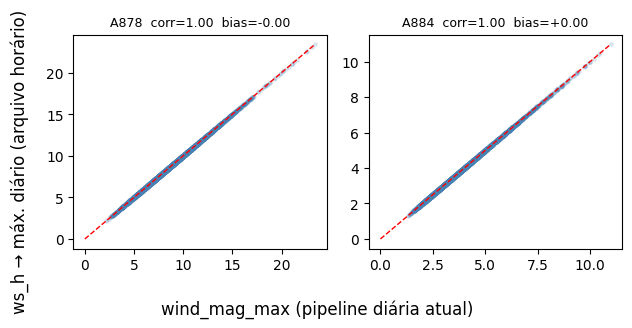

corr — min=1.000  média=1.000  max=1.000


,estacao,corr,bias_m_s,n_dias_comuns
0,A878,1.0,-3.062834e-09,9497
1,A884,1.0,3.749567e-10,9497


In [7]:
loader = NetCDFLoader(raw_dir=str(RAW_DIR))
_, ds_era5_daily = loader.load()

era5_legacy_stations = set(str(s) for s in ds_era5_daily["estacao"].values)
comparaveis = [est for est in HOURLY_STATIONS if est in era5_legacy_stations]
nao_comparaveis = [est for est in HOURLY_STATIONS if est not in era5_legacy_stations]
print(f"Comparáveis contra o ERA5 legado (30 estações): {len(comparaveis)} de {len(HOURLY_STATIONS)}")
if nao_comparaveis:
    print(f"Fora do ERA5 legado, não comparadas: {nao_comparaveis}")

ws_h_daily_max = ds_hourly["ws_h"].resample(time="1D").max()

n = len(comparaveis)
ncols = min(5, max(n, 1))
nrows = -(-n // ncols) if n else 1  # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows), squeeze=False)
axes_flat = axes.flatten()

consistency_rows = []
for ax, est in zip(axes_flat, comparaveis):
    a = ws_h_daily_max.sel(estacao=est).to_series().rename("ws_h_daily_max")
    b = ds_era5_daily["wind_mag_max"].sel(estacao=est).to_series().rename("wind_mag_max")
    joined = pd.concat([a, b], axis=1).dropna()
    corr = joined["ws_h_daily_max"].corr(joined["wind_mag_max"]) if len(joined) else float("nan")
    bias = (joined["ws_h_daily_max"] - joined["wind_mag_max"]).mean() if len(joined) else float("nan")

    ax.scatter(joined["wind_mag_max"], joined["ws_h_daily_max"], alpha=0.15, s=6, color="steelblue")
    lims = [0, max(joined.max().max(), 1) if len(joined) else 1]
    ax.plot(lims, lims, color="red", linewidth=1, linestyle="--")
    ax.set_title(f"{est}  corr={corr:.2f}  bias={bias:+.2f}", fontsize=9)

    consistency_rows.append({"estacao": est, "corr": corr, "bias_m_s": bias, "n_dias_comuns": len(joined)})

for ax in axes_flat[n:]:
    ax.axis("off")

fig.supxlabel("wind_mag_max (pipeline diária atual)")
fig.supylabel("ws_h → máx. diário (arquivo horário)")
plt.tight_layout()
plt.show()

consistency_df = pd.DataFrame(consistency_rows)
if len(consistency_df):
    print(
        f"corr — min={consistency_df['corr'].min():.3f}  "
        f"média={consistency_df['corr'].mean():.3f}  max={consistency_df['corr'].max():.3f}"
    )
consistency_df.sort_values("corr") if len(consistency_df) else consistency_df

## Resumo — para a decisão de escopo

A tabela abaixo é montada a partir das variáveis calculadas nas células
acima (`cluster3_stations`, `coverage_df`) — nenhum nome de estação ou
contagem é repetido à mão.

In [8]:
n_cluster_total = len(cluster3_stations)
n_hourly = len(HOURLY_STATIONS)
com_alvo_atual = coverage_df.loc[coverage_df["tem_alvo_atual"], "estacao"].tolist()
sem_alvo_atual = coverage_df.loc[~coverage_df["tem_alvo_atual"], "estacao"].tolist()
recuperaveis_do_backup = coverage_df.loc[
    (~coverage_df["tem_alvo_atual"]) & (coverage_df["tem_alvo_backup"]), "estacao"
].tolist()

if not sem_alvo_atual:
    resumo_md = f"""
As {n_hourly} estações do arquivo horário têm alvo válido hoje e coincidem
com as {n_cluster_total} estações do Cluster 3 (spatial join atual) —
`faltando_no_hourly` e `extra_no_hourly` (célula acima) devem estar vazios.
Não há gap de cobertura: dá para comparar a pipeline diária e a horária nas
mesmas {n_cluster_total} estações, sem precisar reduzir escopo nem recuperar
alvo de backup.
"""
else:
    resumo_md = f"""
| Opção | O que muda | Prós | Contras |
|---|---|---|---|
| **A. Cluster completo vs. subconjunto horário** | Pipeline diária usa as {n_cluster_total} estações do Cluster 3 (modelo já vencedor, sem alteração); pipeline horária usa só {com_alvo_atual} (as com alvo válido, de {n_hourly} no arquivo) | Reaproveita o `ClusterTrainer` sem nenhuma modificação; representa o Cluster 3 inteiro do lado diário | Comparação não é pareada estação-a-estação |
| **B. Apenas estações pareadas** | Restringe as DUAS pipelines a {com_alvo_atual} (alvo válido E cobertura horária) | Comparação controlada, mesma amostra dos dois lados | Lado diário deixa de representar o cluster inteiro ({len(com_alvo_atual)} de {n_cluster_total} estações) |
| **C. Recuperar alvo de {sem_alvo_atual}** | Usa o backup pré-migração para dar alvo a {recuperaveis_do_backup} e inclui as {n_hourly} estações pareadas nas duas pipelines | Mais fiel à intenção original do arquivo horário | Reintroduz estação(ões) que saíram da migração atual por motivo não investigado |

Os números concretos levantados acima (tabela de cobertura, mapa, cobertura
temporal, completude e a checagem de consistência física) são a base para
escolher entre essas opções antes de desenhar o experimento
diário-vs-horário em si.
"""
display(Markdown(resumo_md))


As 21 estações do arquivo horário têm alvo válido hoje e coincidem
com as 21 estações do Cluster 3 (spatial join atual) —
`faltando_no_hourly` e `extra_no_hourly` (célula acima) devem estar vazios.
Não há gap de cobertura: dá para comparar a pipeline diária e a horária nas
mesmas 21 estações, sem precisar reduzir escopo nem recuperar
alvo de backup.
